In [2]:
%load_ext autoreload
%autoreload 2

from plotting import *
from optimization_utils import smooth_inflow
from param_loader import METANET_Params

In [3]:
lanes = np.load("data/lane_mapping.npy")

i24_rho = np.load("data/density_10sec_400m_1hr.npy") / lanes
i24_q = np.load("data/flow_10sec_400m_1hr.npy")

T = 10/3600
l = 0.4
num_calibrated_segments = 14
downstream_density = smooth_inflow(i24_rho[:, -1])
data_inflow = smooth_inflow(i24_q[:, 0])
i24_v = i24_q/(i24_rho * lanes)
init_traffic_state = (i24_rho[0, 1:-1], i24_v[0, 1:-1], data_inflow[0], 0)

## Plotting robustness curves

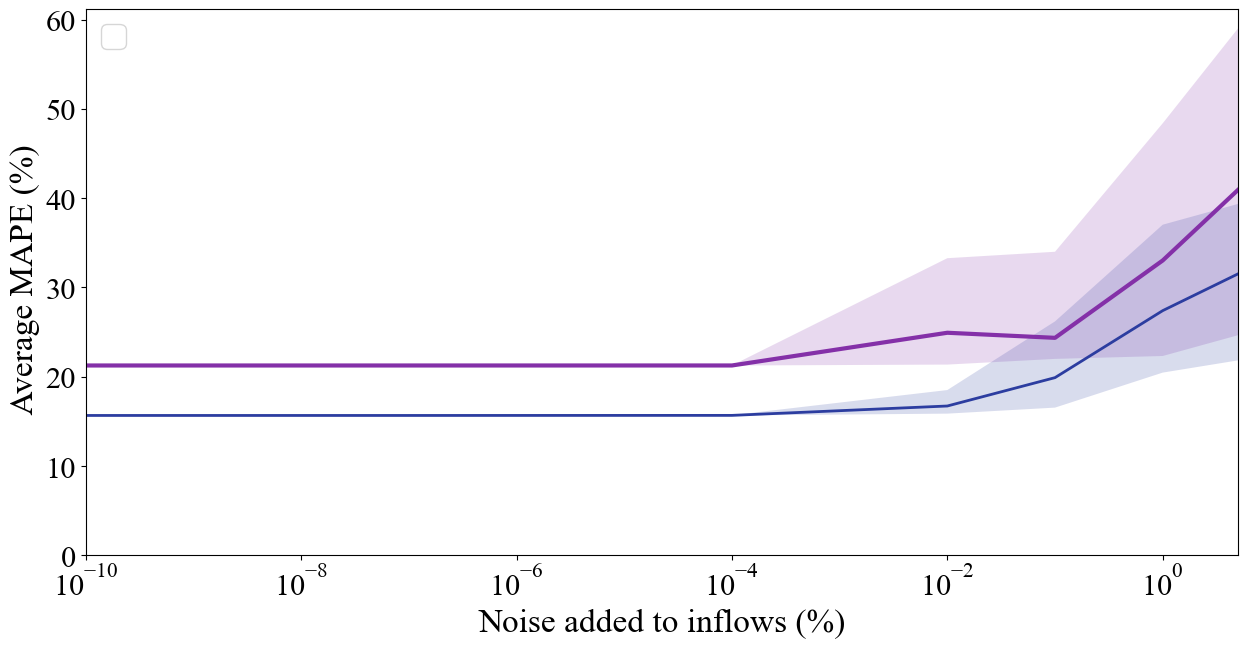

In [9]:
root_dir = "cdc_results/synthetic_data_rain/mpc_calibration_results_var0.2"
dir_to_plot = [f"itsc_final/smooth_mpc_calibration_results/control_h_30",
               # f"{root_dir}/control_h_6",
               # f"{root_dir}/control_h_60",
               # f"{root_dir}/control_h_90",
            #    f"{root_dir}/control_h_120",
            #    f"{root_dir}/control_h_180",
               # f"{root_dir}/control_h_360",
               "robust_mpc_calibration_results/S5/control_h_30",
                # "calibration_results/OCP",
               ]

plot_percentile_curves(dir_to_plot, desired_legend_order=["Dynamic: 5 min", "Robust: 5 min"], metric="mean", percentile=True)

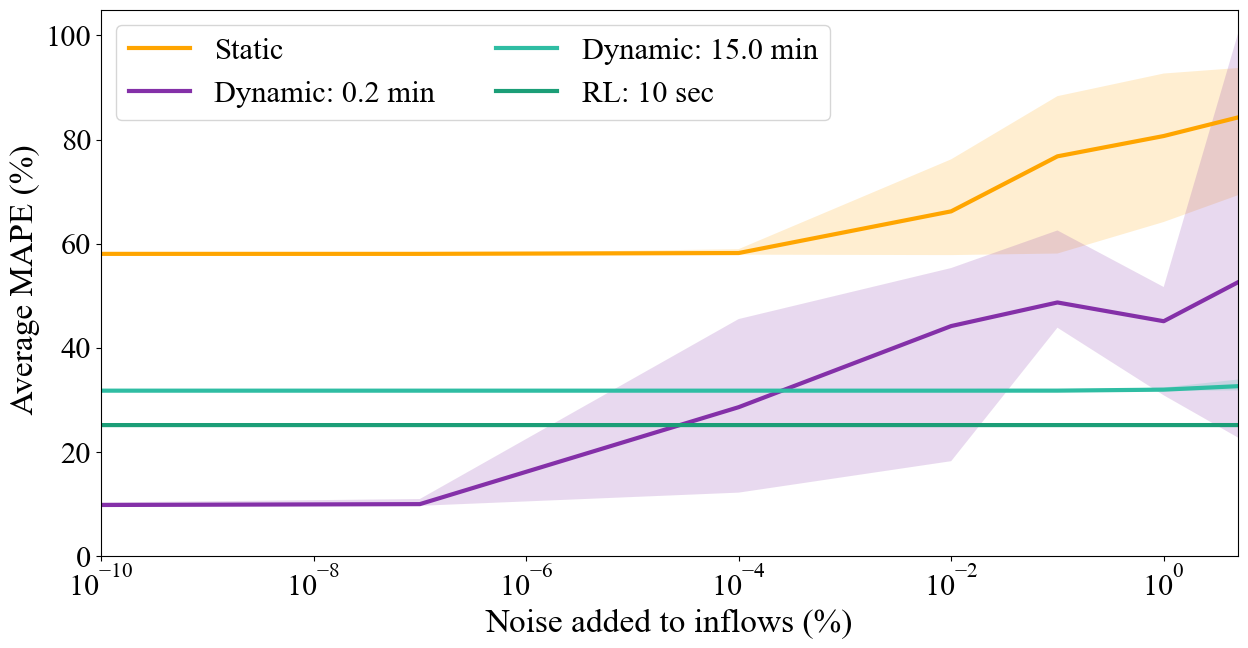

In [18]:
dir_to_plot = ["itsc_final/calibration_results/OCP", 
               "itsc_final/smooth_mpc_calibration_results/control_h_1", 
               "itsc_final/smooth_mpc_calibration_results/control_h_90",  
               "calibration_results/i24_11_30_rl_posttrain_2"]

plot_percentile_curves(dir_to_plot, desired_legend_order=["Static", "Dynamic: 0.2 min", "Dynamic: 15.0 min", "RL: 10 sec"], 
                       metric="mean", g_fontsize=24, percentile=True)

## Plotting perturbation curves

In [ ]:
from eval_metrics import mape
from simulation_utils import run_metanet_sim


Config: OCP (itsc_final/calibration_results/OCP)
Segment: 0
Cache:  smooth_landscape_plots/perturbation_cache/OCP_seg0_bc0_n201_pmin-0.1000_pmax0.1000.npz
  Loading existing perturbation data...

Config: MPC_90 (itsc_final/smooth_mpc_calibration_results/)
Segment: 0
Cache:  smooth_landscape_plots/perturbation_cache/MPC_90_seg0_bc0_n201_pmin-0.1000_pmax0.1000.npz
  Loading existing perturbation data...

Config: RL (calibration_results/i24_11_30_rl_posttrain_2/)
Segment: 0
Cache:  smooth_landscape_plots/perturbation_cache/RL_seg0_bc0_n201_pmin-0.1000_pmax0.1000.npz
  Loading existing perturbation data...


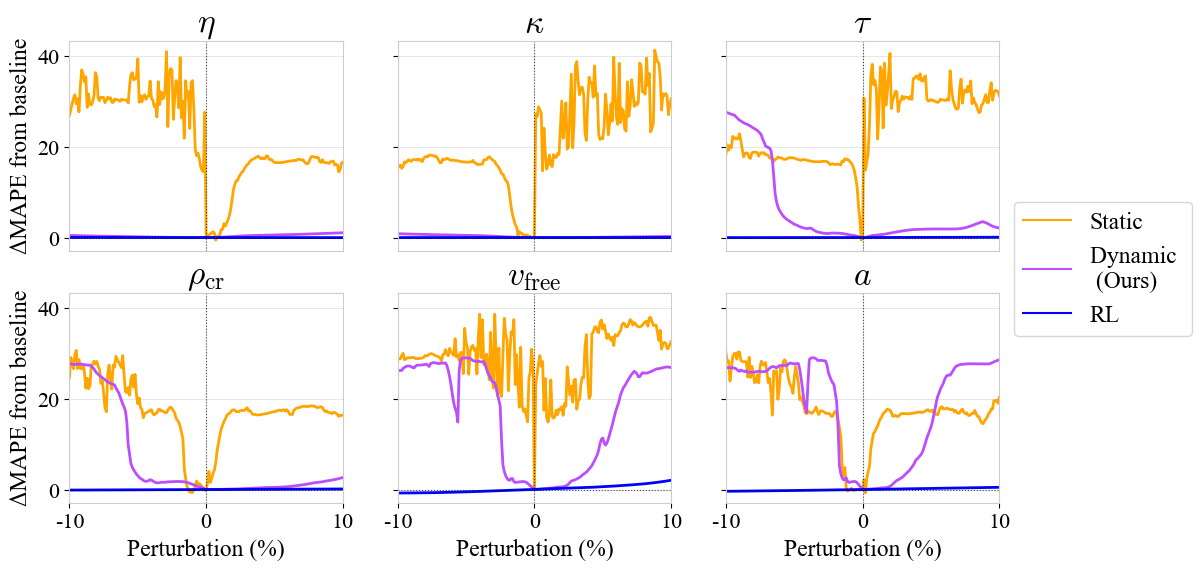


Saved plot to smooth_landscape_plots/sensitivity_comparison_rl_segment0.pdf


<Figure size 640x480 with 0 Axes>

In [ ]:
# Each config specifies its own lanes and preprocessing, matching standalone cells

seg = 0
param_configs = [
    {
        "label": "OCP",
        "results_dir": "itsc_final/calibration_results/OCP",
        "control_hor": None,
        "lanes": lanes[1:-1],
        "smooth_rho": False,
        "smooth_bc": True,
        "segment_idx": seg,      # optional, defaults to 7
        "bc_timestep": 0,    # optional, defaults to 180
        "rho_hat": i24_rho,
        "q_hat": i24_q,
    },
    {
        "label": "MPC_90",
        "results_dir": "itsc_final/smooth_mpc_calibration_results/",
        "control_hor": 90,
        "lanes": lanes[1:-1],
        "smooth_rho": False,
        "smooth_bc": True,
        "segment_idx": seg,      # optional, defaults to 7
        "bc_timestep": 0,    # optional, defaults to 180
        "rho_hat": i24_rho,
        "q_hat": i24_q,
    },
    {
        "label": "RL",
        "results_dir": "calibration_results/i24_11_30_rl_posttrain_2/",
        "control_hor": None,
        "lanes": lanes[1:-1],
        "smooth_rho": False,
        "smooth_bc": True,
        "segment_idx": seg,      # optional, defaults to 7
        "bc_timestep": 0,    # optional, defaults to 180
        "rho_hat": i24_rho,
        "q_hat": i24_q,
    }
]

all_results = run_and_plot_perturbations(
    param_configs=param_configs,
    T=T, l=l,
    num_calibrated_segments=num_calibrated_segments,
    run_metanet_sim=run_metanet_sim,
    mape_fn=mape,
    save_path=f"smooth_landscape_plots/sensitivity_comparison_rl_segment{seg}.pdf",
    cache_dir="smooth_landscape_plots/perturbation_cache",
    use_cache=True,
    load_only=False,
    g_fontsize=16,
)


## MPC Horizon comparison

## Time-space diagrams from noisy inflows

## Fundamental diagram comparison

In [4]:
scenario = {
    "T": T,
    "l": l,
    "lanes": lanes[1:-1],
    "num_calibrated_segments": num_calibrated_segments,
    "rho_hat": i24_rho,
    "q_hat": i24_q,
    "init_traffic_state": init_traffic_state,
    "downstream_density": downstream_density,
    "data_inflow": data_inflow,
}

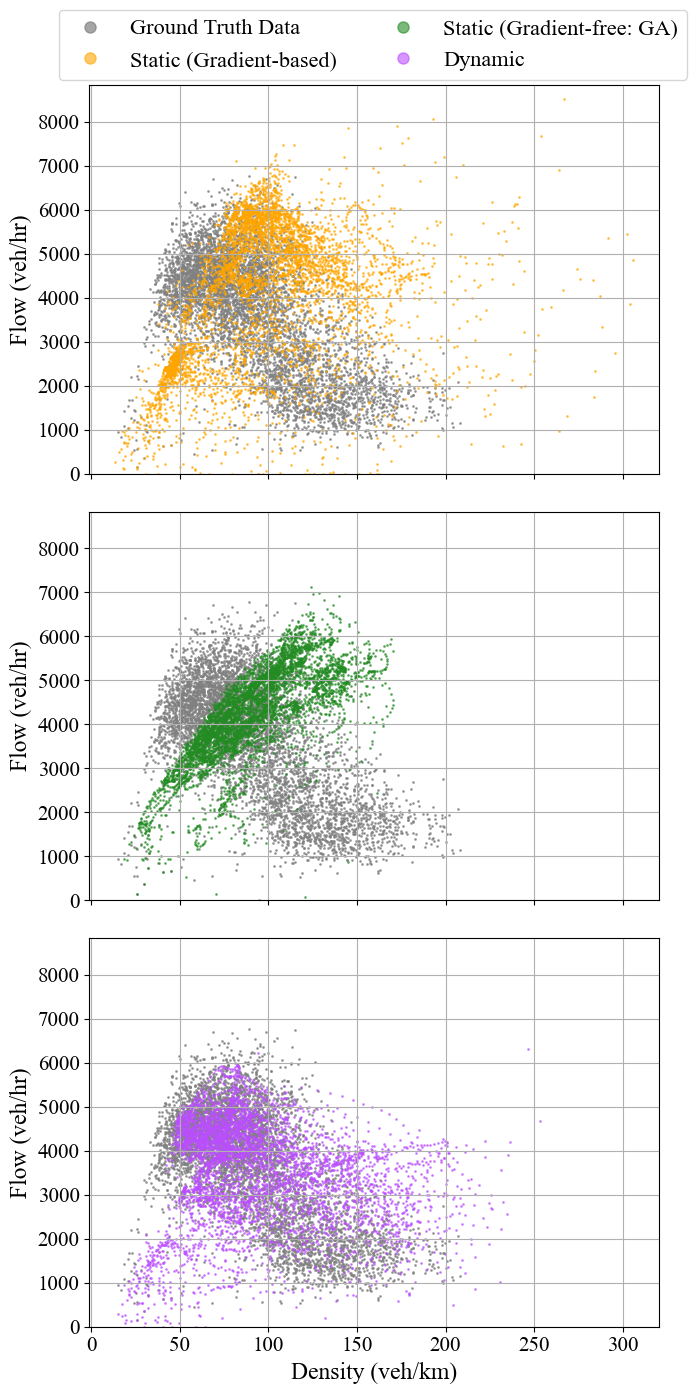

In [8]:
plot_fd_diagrams([METANET_Params("itsc_final/calibration_results/OCP").get_params(), 
                  METANET_Params("ga_calibration_results/trials2500").get_params(),
                  METANET_Params("itsc_final/smooth_mpc_calibration_results", control_h=90, num_timesteps=360).get_params()], 
                #   METANET_Params("calibration_results/i24_11_30_rl_posttrain_2").get_params()],
                 scenario_info=scenario,
                 labels=["Static (Gradient-based)",  "Static (Gradient-free: GA)", "Dynamic"],
                 save_path="itsc_final/figs/FD_comparison.pdf") # "RL (10 sec)"])